## IMPORT LIBRARIES

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## LOAD DATASET

In [37]:
df = pd.read_csv("/content/Battery_Dataset.csv")
df.head()

,type,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,-1,4,47,0,1,00001.csv,0.983689,0.054543,0.183130
1,0,24,47,1,2,00002.csv,0.983689,0.054543,0.183130
2,1,4,47,2,3,00003.csv,0.983689,0.054543,0.183130
3,0,24,47,3,4,00004.csv,0.983689,0.051825,0.152493
4,-1,4,47,4,5,00005.csv,0.925990,0.051825,0.152493


## DATA UNDERSTANDING

In [38]:
df.shape

(7368, 9)

In [39]:
df.columns

Index(['type', 'ambient_temperature', 'battery_id', 'test_id', 'uid',
       'filename', 'Capacity', 'Re', 'Rct'],
      dtype='object')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7368 entries, 0 to 7367
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 7368 non-null   int64  
 1   ambient_temperature  7368 non-null   int64  
 2   battery_id           7368 non-null   int64  
 3   test_id              7368 non-null   int64  
 4   uid                  7368 non-null   int64  
 5   filename             7368 non-null   object 
 6   Capacity             7368 non-null   float64
 7   Re                   7368 non-null   float64
 8   Rct                  7368 non-null   float64
dtypes: float64(3), int64(5), object(1)
memory usage: 518.2+ KB


## CHECK FOR MISSING VALUES

In [41]:
df.isnull().sum()

,0
type,0
ambient_temperature,0
battery_id,0
test_id,0
uid,0
filename,0
Capacity,0
Re,0
Rct,0


## DATA CLEANING

In [42]:
df = df.dropna()

## DESCRIPTIVE STATISTICS

In [43]:
df.describe()

,type,ambient_temperature,battery_id,test_id,uid,Capacity,Re,Rct
count,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000
mean,0.002443,19.911238,32.213762,166.309718,3735.133415,0.824926,0.077739,0.125128
std,0.865297,11.210718,16.643714,139.771878,2190.232696,0.250283,0.022584,0.044834
min,-1.000000,4.000000,5.000000,0.000000,1.000000,0.000000,0.026691,0.038781
25%,-1.000000,4.000000,18.000000,54.000000,1842.750000,0.775098,0.060875,0.084685
50%,0.000000,24.000000,36.000000,125.000000,3686.500000,0.894803,0.074693,0.118383
75%,1.000000,24.000000,45.000000,244.250000,5603.250000,0.986519,0.095817,0.158926
max,1.000000,44.000000,56.000000,555.000000,7565.000000,1.292025,0.142128,0.238124


## DATA VISUALISATION

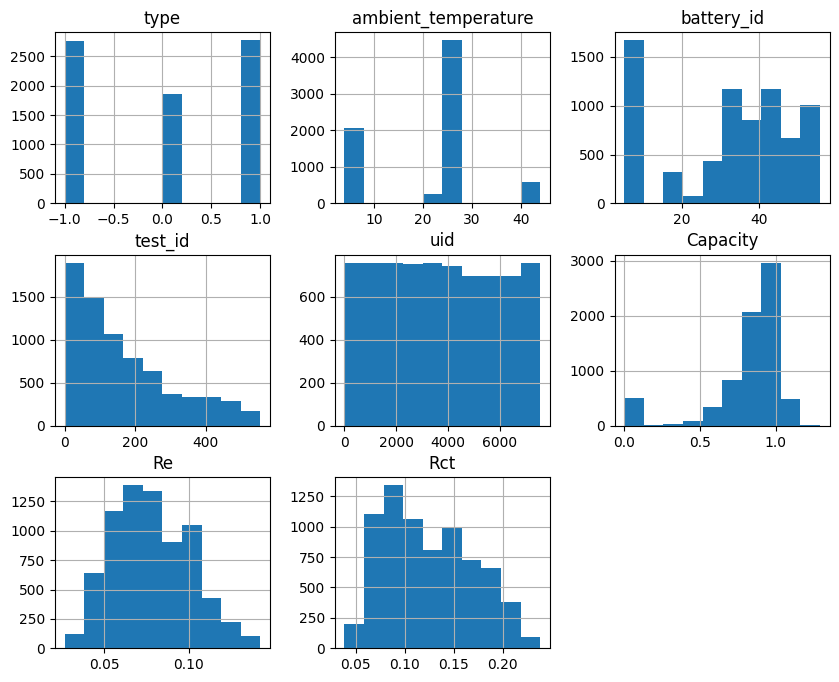

In [44]:
# Histogram

df.hist(figsize=(10,8))
plt.show()

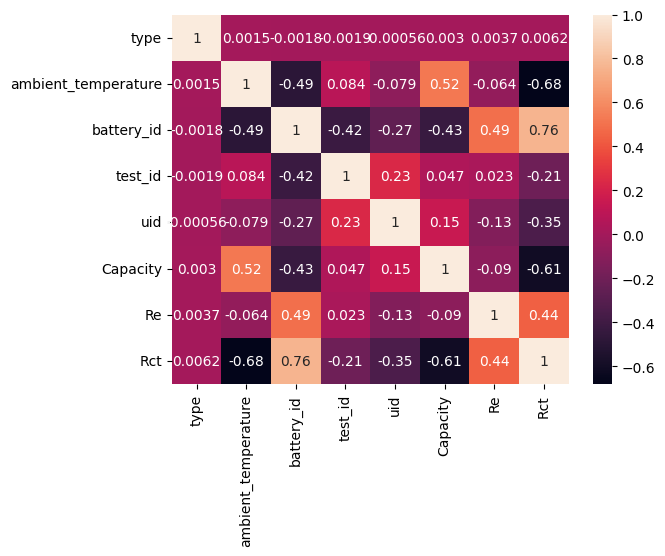

In [45]:
# Correlation heatmap
df_numeric = df.select_dtypes(include=[np.number])
sns.heatmap(df_numeric.corr(), annot=True)
plt.show()

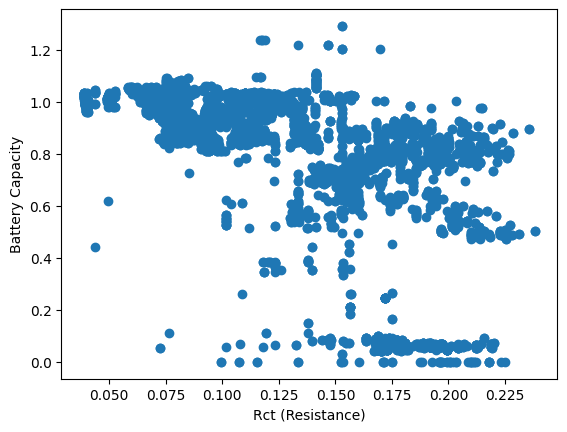

In [46]:
# Scatter plot

plt.scatter(df["Rct"], df["Capacity"])
plt.xlabel("Rct (Resistance)")
plt.ylabel("Battery Capacity")
plt.show()

## TRAIN - TEST SPLIT

In [47]:
from sklearn.model_selection import train_test_split

X = df[["ambient_temperature", "Re", "Rct"]]
y = df["Capacity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## MACHINE LEARNING MODEL ( LINEAR REGRESSION )

In [48]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## PREDICTIONS

In [49]:
y_pred = model.predict(X_test)

## MODEL EVALUATION

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 0.1265480713258329
MSE: 0.03937746374348752


In [53]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.40694300543799844


## MODEL GRAPH

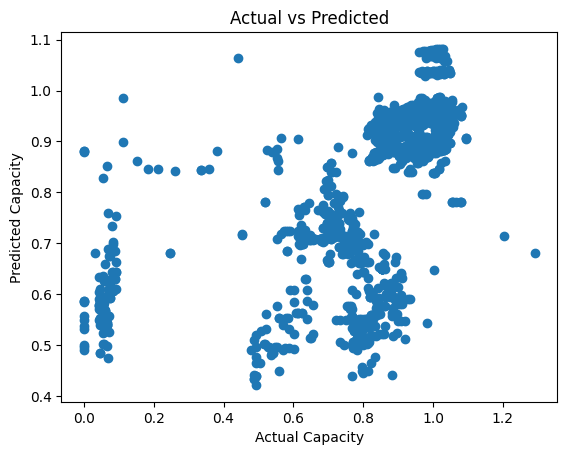

In [54]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Capacity")
plt.ylabel("Predicted Capacity")
plt.title("Actual vs Predicted")
plt.show()